[Previous: Module 3: Hash Tables and Sets](03_Hash_Tables_and_Sets.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 5: Trees and Heaps](05_Trees_and_Heaps.ipynb)

# Module 4: Recursion, Searching and Sorting

**Learning objectives.** After this module you can:

* write a recursive function with a correct base case and trace its calls;
* explain divide and conquer, and why splitting in half gives $O(n \log n)$;
* implement bubble, insertion, merge and quick sort from memory and compare them on the same input;
* use `sorted` with keys and `bisect` for sorted data, and know what stability means.

**Prerequisites.** [Module 1](01_Complexity_and_Big_O.ipynb) and [Module 2](02_Arrays_Linked_Lists_Stacks_Queues.ipynb).

## 1. Recursion: a function that trusts itself

A recursive function solves a problem by solving a **smaller instance of the same problem** and doing a little extra work. Two ingredients are mandatory:

* a **base case** small enough to answer directly;
* a **recursive case** that moves strictly towards the base case.

Miss the first and the calls never end; Python stops you with `RecursionError` after about a thousand frames.
Naive Fibonacci below is correct but calls itself an absurd number of times, which is the problem Module 7 fixes.

In [1]:
import random, sys, bisect
import matplotlib.pyplot as plt
from dsalab import time_it, growth_plot, draw_array

def power(base, exp):                       # base case exp == 0, recursive case exp - 1
    return 1 if exp == 0 else base * power(base, exp - 1)

print("2 ** 10 by recursion:", power(2, 10))

calls = 0
def fib(n):
    global calls
    calls += 1
    return n if n < 2 else fib(n - 1) + fib(n - 2)

for n in [10, 20, 25]:
    calls = 0
    value = fib(n)
    print(f"fib({n}) = {value:>6}   calls = {calls:>9,}")

2 ** 10 by recursion: 1024
fib(10) =     55   calls =       177
fib(20) =   6765   calls =    21,891
fib(25) =  75025   calls =   242,785


## 2. Divide and conquer

Split the input in half, solve both halves recursively, combine. Binary search is the simplest case: it discards one half and recurses on the other,
giving $\log_2 n$ levels of O(1) work. Merge sort recurses on **both** halves and merges in O(n), giving $\log_2 n$ levels of O(n) work: $O(n \log n)$.

The trace below prints every split and every merge of a merge sort, indented by recursion depth. Read it top to bottom to see the tree.

In [2]:
def binary_search_rec(items, target, lo=0, hi=None):
    hi = len(items) - 1 if hi is None else hi
    if lo > hi:
        return -1
    mid = (lo + hi) // 2
    if items[mid] == target:
        return mid
    if items[mid] < target:
        return binary_search_rec(items, target, mid + 1, hi)
    return binary_search_rec(items, target, lo, mid - 1)

print("recursive binary search:", binary_search_rec(list(range(0, 100, 5)), 35))

def merge(left, right):
    out, i, j = [], 0, 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            out.append(left[i]); i += 1
        else:
            out.append(right[j]); j += 1
    return out + left[i:] + right[j:]

def merge_sort(a, depth=0, trace=False):
    if trace: print("    " * depth + f"split {a}")
    if len(a) <= 1:
        return list(a)
    mid = len(a) // 2
    left = merge_sort(a[:mid], depth + 1, trace)
    right = merge_sort(a[mid:], depth + 1, trace)
    merged = merge(left, right)
    if trace: print("    " * depth + f"merge {left} + {right} -> {merged}")
    return merged

merge_sort([38, 27, 43, 3, 9, 82, 10], trace=True);

recursive binary search: 7
split [38, 27, 43, 3, 9, 82, 10]
    split [38, 27, 43]
        split [38]
        split [27, 43]
            split [27]
            split [43]
        merge [27] + [43] -> [27, 43]
    merge [38] + [27, 43] -> [27, 38, 43]
    split [3, 9, 82, 10]
        split [3, 9]
            split [3]
            split [9]
        merge [3] + [9] -> [3, 9]
        split [82, 10]
            split [82]
            split [10]
        merge [82] + [10] -> [10, 82]
    merge [3, 9] + [10, 82] -> [3, 9, 10, 82]
merge [27, 38, 43] + [3, 9, 10, 82] -> [3, 9, 10, 27, 38, 43, 82]


## 3. Four sorting algorithms

| Algorithm | Idea | Time | Space | Stable |
|-----------|------|------|-------|--------|
| Bubble | swap neighbours that are out of order, repeat | $O(n^2)$ | O(1) | yes |
| Insertion | take the next item, slide it left into place | $O(n^2)$, but O(n) on nearly sorted input | O(1) | yes |
| Merge | split, sort halves, merge | $O(n \log n)$ always | O(n) | yes |
| Quick | pick a pivot, partition smaller left and larger right, recurse | $O(n \log n)$ average, $O(n^2)$ worst | O(log n) | no |

**Stable** means equal items keep their relative order, which matters when you sort records by one field after another.
All four below are written to be read, not to be fast, and each is checked against Python's `sorted`.

In [3]:
def bubble_sort(a):
    a = list(a)
    for i in range(len(a)):
        swapped = False
        for j in range(len(a) - 1 - i):
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                swapped = True
        if not swapped:                      # already sorted: stop early
            break
    return a

def insertion_sort(a):
    a = list(a)
    for i in range(1, len(a)):
        x, j = a[i], i - 1
        while j >= 0 and a[j] > x:           # slide larger items right
            a[j + 1] = a[j]
            j -= 1
        a[j + 1] = x
    return a

def quick_sort(a):
    if len(a) <= 1:
        return list(a)
    pivot = a[len(a) // 2]
    smaller = [x for x in a if x < pivot]
    equal = [x for x in a if x == pivot]
    larger = [x for x in a if x > pivot]
    return quick_sort(smaller) + equal + quick_sort(larger)

random.seed(4)
sample = random.sample(range(100), 12)
print("input:    ", sample)
for name, fn in [("bubble", bubble_sort), ("insertion", insertion_sort), ("merge", merge_sort), ("quick", quick_sort)]:
    out = fn(sample)
    print(f"{name:<10}", out, "" if out == sorted(sample) else "  <-- WRONG")

input:     [30, 38, 13, 92, 50, 61, 19, 11, 8, 2, 51, 70]
bubble     [2, 8, 11, 13, 19, 30, 38, 50, 51, 61, 70, 92] 
insertion  [2, 8, 11, 13, 19, 30, 38, 50, 51, 61, 70, 92] 
merge      [2, 8, 11, 13, 19, 30, 38, 50, 51, 61, 70, 92] 
quick      [2, 8, 11, 13, 19, 30, 38, 50, 51, 61, 70, 92] 


### Lab: Sorting Visualiser

Press play. Green bars have reached their final position. Compare the step counts under the chart: on the same input, bubble sort does hundreds of swaps
where merge sort does a few dozen writes. Try the largest size and watch bubble sort crawl.

Sorting Visualiser (static preview). Run this cell in JupyterLab for the interactive version.


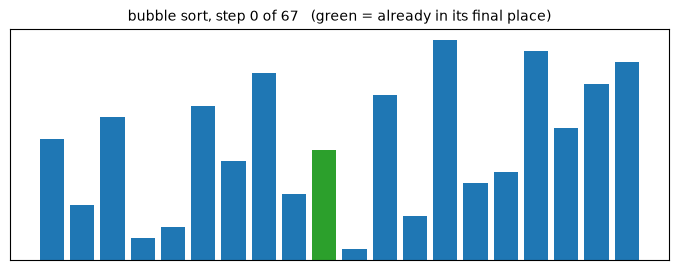

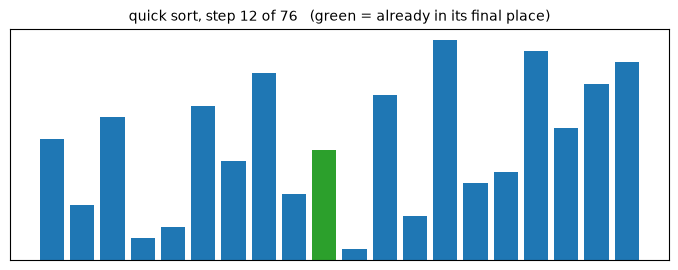

In [4]:
from dsalab import sorting_visualizer

sorting_visualizer()

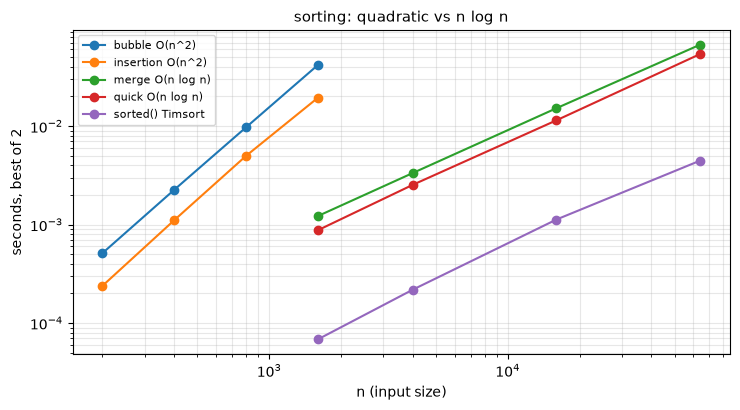

In [5]:
# The measurement. Quadratic sorts get small inputs; the others get inputs up to 64,000.
random.seed(5)
INPUTS = {n: [random.random() for _ in range(n)] for n in [200, 400, 800, 1600, 4000, 16000, 64000]}

growth_plot(
    {"bubble O(n^2)": lambda n: bubble_sort(INPUTS[n]), "insertion O(n^2)": lambda n: insertion_sort(INPUTS[n]),
     "merge O(n log n)": lambda n: merge_sort(INPUTS[n]), "quick O(n log n)": lambda n: quick_sort(INPUTS[n]),
     "sorted() Timsort": lambda n: sorted(INPUTS[n])},
    {"bubble O(n^2)": [200, 400, 800, 1600], "insertion O(n^2)": [200, 400, 800, 1600],
     "merge O(n log n)": [1600, 4000, 16000, 64000], "quick O(n log n)": [1600, 4000, 16000, 64000],
     "sorted() Timsort": [1600, 4000, 16000, 64000]},
    title="sorting: quadratic vs n log n", repeats=2,
)

> **What to notice.** The two quadratic curves have slope 2, the three others slope about 1. `sorted()` sits far below the Python implementations
> because it runs in C, but its slope is the same as merge sort's: same algorithm class, smaller constant. Never write your own sort in production; do know how they work.

## 4. Sorting in practice: keys, stability, bisect

Python's `sorted` is **Timsort**: merge sort with insertion sort on small runs, O(n log n), stable, and O(n) on already sorted input.
Sort by any field with `key=`. Because it is stable, sorting by one key and then another gives "then by" ordering.
For data that stays sorted, `bisect` finds positions in O(log n).

In [6]:
people = [("dana", 31), ("bob", 25), ("alice", 31), ("carl", 25)]
print("by age:              ", sorted(people, key=lambda p: p[1]))
print("by age, ties by name:", sorted(sorted(people), key=lambda p: p[1]))   # stable: inner sort order survives
print("by age descending:   ", sorted(people, key=lambda p: -p[1]))

scores = [10, 20, 30, 40, 50]
print("\nbisect: 35 would go at index", bisect.bisect_left(scores, 35))
bisect.insort(scores, 35)
print("after insort:", scores, "(the insert itself is O(n), the search O(log n))")

by age:               [('bob', 25), ('carl', 25), ('dana', 31), ('alice', 31)]
by age, ties by name: [('bob', 25), ('carl', 25), ('alice', 31), ('dana', 31)]
by age descending:    [('dana', 31), ('alice', 31), ('bob', 25), ('carl', 25)]

bisect: 35 would go at index 3
after insort: [10, 20, 30, 35, 40, 50] (the insert itself is O(n), the search O(log n))


## Try it yourself

**Exercise 1.** Write `count_inversions(a)`: the number of pairs $i < j$ with $a[i] > a[j]$. The O(n^2) version is two loops; the O(n log n) version counts during merge sort's merge step.

**Exercise 2.** Implement **quickselect** to find the k-th smallest item in O(n) average without fully sorting.

**Exercise 3.** Use binary search to compute the integer square root of n (the largest x with x*x <= n) in O(log n). This is "binary search on the answer".

**Exercise 4 (challenge).** Make `quick_sort` sort in place with the Lomuto partition (as the visualiser does) and measure whether it beats the list-building version.

<details><summary>Solutions</summary>

```python
# Exercise 1
def count_inversions(a):
    if len(a) <= 1: return 0, list(a)
    mid = len(a) // 2
    li, left = count_inversions(a[:mid]); ri, right = count_inversions(a[mid:])
    out, i, j, inv = [], 0, 0, li + ri
    while i < len(left) and j < len(right):
        if left[i] <= right[j]: out.append(left[i]); i += 1
        else: out.append(right[j]); j += 1; inv += len(left) - i     # every remaining left item is larger
    return inv, out + left[i:] + right[j:]
print(count_inversions([2, 4, 1, 3, 5])[0])      # 3

# Exercise 2
def quickselect(a, k):
    pivot = random.choice(a)
    smaller = [x for x in a if x < pivot]; equal = [x for x in a if x == pivot]; larger = [x for x in a if x > pivot]
    if k < len(smaller): return quickselect(smaller, k)
    if k < len(smaller) + len(equal): return pivot
    return quickselect(larger, k - len(smaller) - len(equal))
print(quickselect([9, 1, 8, 2, 7, 3], 2))        # 3

# Exercise 3
def isqrt(n):
    lo, hi = 0, n
    while lo < hi:
        mid = (lo + hi + 1) // 2
        if mid * mid <= n: lo = mid
        else: hi = mid - 1
    return lo
print(isqrt(10**12 + 7))

# Exercise 4
def quick_sort_inplace(a, lo=0, hi=None):
    hi = len(a) - 1 if hi is None else hi
    if lo < hi:
        pivot, i = a[hi], lo
        for j in range(lo, hi):
            if a[j] < pivot: a[i], a[j] = a[j], a[i]; i += 1
        a[i], a[hi] = a[hi], a[i]
        quick_sort_inplace(a, lo, i - 1); quick_sort_inplace(a, i + 1, hi)
    return a
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [7]:
from dsalab import quiz

quiz(4)

Checkpoint quiz, Module 4 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Every recursive function needs
    a) a loop
    b) a base case that stops the recursion
    c) a global variable
    d) at least two arguments

Q2. Merge sort's running time is
    a) O(n log n) in every case
    b) O(n^2) in the worst case
    c) O(n) on sorted input
    d) O(log n)

Q3. Quicksort's worst case happens when
    a) the input has duplicates
    b) the pivot is always the smallest or largest element
    c) n is odd
    d) the input is random

Q4. Python's built-in sorted() uses
    a) bubble sort
    b) quicksort
    c) Timsort, a hybrid of merge sort and insertion sort
    d) heap sort


## Key takeaways

* Recursion needs a base case and a step towards it; the call stack does the bookkeeping.
* Divide and conquer: halve, recurse, combine. Log n levels of linear work is n log n.
* Bubble and insertion sort are O(n^2); merge and quick sort are O(n log n). `sorted()` is Timsort, use it.
* Stability lets you chain sorts by key; `bisect` searches sorted lists in O(log n).

**Next:** the structure that keeps data sorted while it changes. [Module 5](05_Trees_and_Heaps.ipynb).

[Previous: Module 3: Hash Tables and Sets](03_Hash_Tables_and_Sets.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 5: Trees and Heaps](05_Trees_and_Heaps.ipynb)